In [1]:
# --- セル1: ライブラリの準備 ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import MeCab
import ipadic
import joblib
import os
import re
import itertools # パラメータ探索用

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# 日本語フォント設定
plt.rcParams['font.family'] = 'Meiryo'
plt.rcParams['axes.unicode_minus'] = False

print("ライブラリのインポート完了")

KeyboardInterrupt: 

In [ ]:
# --- セル2: データ読み込みと前処理（文字数制限・サンプリング） ---
csv_path = 'dataset/narou_dataset.csv'
df = pd.read_csv(csv_path)

# 欠損値埋め
df['あらすじ'] = df['あらすじ'].fillna('')

# ==========================================
TARGET_GENRE_ID = None
genres_map = {
    0: '未設定', 101: '異世界（恋愛）', 102: '現実世界（恋愛）',
    201: 'ハイファンタジー', 202: 'ローファンタジー',
    301: '純文学', 302: 'ヒューマンドラマ', 303: '歴史',
    304: '推理', 305: 'ホラー', 306: 'アクション', 307: 'コメディー',
    401: 'VRゲーム', 402: '宇宙', 403: '空想科学', 404: 'パニック',
    9901: '童話', 9902: '詩', 9903: 'エッセイ', 9904: 'リプレイ',
    9999: 'その他', 9801: 'ノンジャンル'
}
genre_name = genres_map.get(TARGET_GENRE_ID, 'all')

# 1. 文字数によるフィルタリング (20文字未満を除外)

#df['length'] = df['あらすじ'].str.len()
#df_filtered = df[df['length'] >= 20].copy()
df_filtered=df.copy()

print(f"元データ数: {len(df)} -> 20文字以上: {len(df_filtered)}")

# 2. ジャンルで絞り込み
if TARGET_GENRE_ID is not None:
    df_genre = df_filtered[df_filtered['作品ジャンル'] == TARGET_GENRE_ID].copy()
else:
    df_genre = df_filtered.copy()

print(f"ジャンル選択後 ({genre_name}): {len(df_genre)}件")

# 3. エタる群(1)と完結群(0)の均衡化 (Undersampling)
df_eternal = df_genre[df_genre['is_eternal'] == 1]
df_complete = df_genre[df_genre['is_eternal'] == 0]

min_count = min(len(df_eternal), len(df_complete))

if min_count == 0:
    raise ValueError("データ件数が0件のクラスがあります。ジャンルを変更するか、条件を見直してください。")

# 少ない方に合わせてランダム抽出
df_eternal_sampled = df_eternal.sample(n=min_count, random_state=42)
df_complete_sampled = df_complete.sample(n=min_count, random_state=42)

# 結合してシャッフル
df_balanced = pd.concat([df_eternal_sampled, df_complete_sampled]).sample(frac=1, random_state=42)

# 学習データ作成
X_text = df_balanced['あらすじ'].values
y = df_balanced['is_eternal'].values

print("-" * 30)
print(f"分析に使用するデータ数: {len(df_balanced)}件 (各クラス {min_count}件)")
print("データ前処理完了")

元データ数: 537829 -> 20文字以上: 537829
ジャンル選択後 (all): 537829件
------------------------------
分析に使用するデータ数: 292486件 (各クラス 146243件)
データ前処理完了


In [ ]:
# --- セル3: 日本語前処理関数の定義 (URL除去・改良版) ---
chaser = MeCab.Tagger(ipadic.MECAB_ARGS)

def japanese_tokenizer(text):
    """
    日本語の文章を単語リストに変換する関数
    1. URLを <URL> に置換
    2. 名詞・動詞・形容詞・接頭詞 を抽出
    3. 動詞や形容詞は「原形」に統一
    """
    text = str(text)
    
    # URLを <URL> という文字列に置換
    text = re.sub(r'https?://[\w/:%#\$&\?\(\)~\.=\+\-]+', '<URL>', text)
    
    parsed = chaser.parse(text)
    words = []
    
    for line in parsed.split('\n'):
        if line == 'EOS' or line == '':
            continue
            
        parts = line.split('\t')
        word_surface = parts[0]
        features = parts[1].split(',')
        
        pos = features[0] # 品詞
        target_pos = ['名詞', '動詞', '形容詞', '接頭詞']
        
        if pos in target_pos:
            # 不要な名詞を除外 (非自立, 代名詞, 数)
            if features[1] in ['非自立', '代名詞', '数']:
                continue
                
            # 原形があればそれを使う
            if len(features) > 6 and features[6] != '*':
                word = features[6]
            else:
                word = word_surface
                
            words.append(word)
            
    return words

# 動作確認
sample = "詳細はこちら https://ncode.syosetu.com/n1234/ を見てください。"
print(f"トークナイズテスト:\n原文: {sample}\n結果: {japanese_tokenizer(sample)}")

トークナイズテスト:
原文: 詳細はこちら https://ncode.syosetu.com/n1234/ を見てください。
結果: ['詳細', 'URL', '見る']


パラメータ探索を開始します...
検証パターン数: 15通り


【最良結果】
正解率: 0.6919
パラメータ: 次元数=20000, 正則化(C)=0.2

+--------------+----------+----------+----------+----------+----------+
| Features \ C |   0.05   |   0.08   |   0.1    |   0.2    |   0.5    |
+--------------+----------+----------+----------+----------+----------+
|    18000     |  0.6836  |  0.6874  |  0.6896  |  0.6911  |  0.6908  |
+--------------+----------+----------+----------+----------+----------+
|    20000     |  0.6839  |  0.6877  |  0.6894  |  0.6919  |  0.6916  |
+--------------+----------+----------+----------+----------+----------+
|    22000     |  0.6841  |  0.6875  |  0.6893  |  0.6918  |  0.6909  |
+--------------+----------+----------+----------+----------+----------+


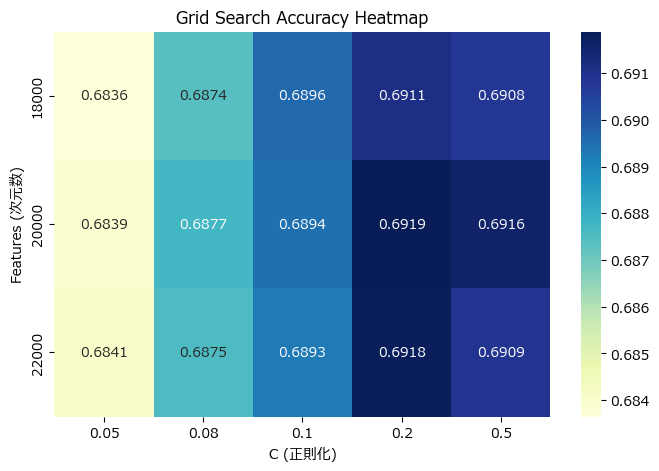

In [ ]:
# --- セル4: グリッドサーチによる精度検証（列幅調整版） ---
import itertools
import warnings
import seaborn as sns

# 警告を無視
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

print("パラメータ探索を開始します...")

# 検証パラメータ(上2行が大雑把に、下2行が細かく)
# --------------------------------------------------
param_max_features = [1000, 5000, 10000, 20000]
param_C = [0.1, 1.0, 5.0, 10.0]
param_max_features = [18000, 20000, 22000]
param_C = [0.05, 0.08, 0.1, 0.2, 0.5]
# --------------------------------------------------

min_df_val = 5
ngram_range_val = (1, 3)

best_score = 0
best_model = None
best_params = {}
results_list = []

combinations = list(itertools.product(param_max_features, param_C))
print(f"検証パターン数: {len(combinations)}通り\n")

for max_feat, c_val in combinations:
    
    current_pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(
            tokenizer=japanese_tokenizer, 
            max_features=max_feat,
            ngram_range=ngram_range_val, 
            min_df=min_df_val,
        )),
        ('clf', LogisticRegression(
            C=c_val,
            solver='liblinear', 
            class_weight='balanced', 
            random_state=42
        ))
    ])

    X_train, X_test, y_train, y_test = train_test_split(
        X_text, y, test_size=0.2, random_state=42, stratify=y
    )

    current_pipeline.fit(X_train, y_train)
    y_pred = current_pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    results_list.append({
        'max_features': max_feat,
        'C': c_val,
        'accuracy': acc
    })
    
    if acc > best_score:
        best_score = acc
        best_model = current_pipeline
        best_params = {'max_features': max_feat, 'C': c_val}

# --- 結果の表示 ---
print("\n" + "="*40)
print(f"【最良結果】")
print(f"正解率: {best_score:.4f}")
print(f"パラメータ: 次元数={best_params['max_features']}, 正則化(C)={best_params['C']}")
print("="*40 + "\n")

# データフレーム化
results_df = pd.DataFrame(results_list)
pivot_table = results_df.pivot(index='max_features', columns='C', values='accuracy')

# 左上のラベル設定
pivot_table.index.name = "Features \\ C"
pivot_table.columns.name = None

# --- 手動で格子状の表を作成して表示 ---
def print_grid_table(df):
    # ヘッダー作成
    headers = [df.index.name] + [str(c) for c in df.columns]
    
    # ★修正箇所: 列幅の計算ロジックを変更
    col_widths = []
    for i, h in enumerate(headers):
        if i == 0:
            # 1列目（左端）はラベルが長いので広めに（最低12文字）
            col_widths.append(max(len(h), 12))
        else:
            # 2列目以降（数値）は狭くする（最低8文字あれば足りる）
            col_widths.append(max(len(h), 8))

    # 区切り線
    def print_separator(char='-'):
        line = '+' + '+'.join([char * (w + 2) for w in col_widths]) + '+'
        print(line)

    print_separator()
    
    # ヘッダー行出力
    header_str = '|'
    for i, h in enumerate(headers):
        header_str += f" {h:^{col_widths[i]}} |"
    print(header_str)
    print_separator()

    # データ行出力
    for idx, row in df.iterrows():
        # インデックス（左端）
        row_str = f"| {str(idx):^{col_widths[0]}} |"
        # データ部分
        for i, col in enumerate(df.columns):
            val = row[col]
            # 値の表示幅
            row_str += f" {val:^{col_widths[i+1]}.4f} |"
        print(row_str)
        print_separator()

print_grid_table(pivot_table)

# ヒートマップ表示
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_table, annot=True, fmt=".4f", cmap="YlGnBu")
plt.title("Grid Search Accuracy Heatmap")
plt.ylabel("Features (次元数)")
plt.xlabel("C (正則化)")
plt.show()

text_pipeline = best_model

C:\Users\blast\AppData\Local\Temp\ipykernel_21380\3698455317.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_eternal, y='word', x='coefficient', ax=axes[0], palette='Reds_r')
C:\Users\blast\AppData\Local\Temp\ipykernel_21380\3698455317.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_complete, y='word', x='coefficient', ax=axes[1], palette='Blues_r')


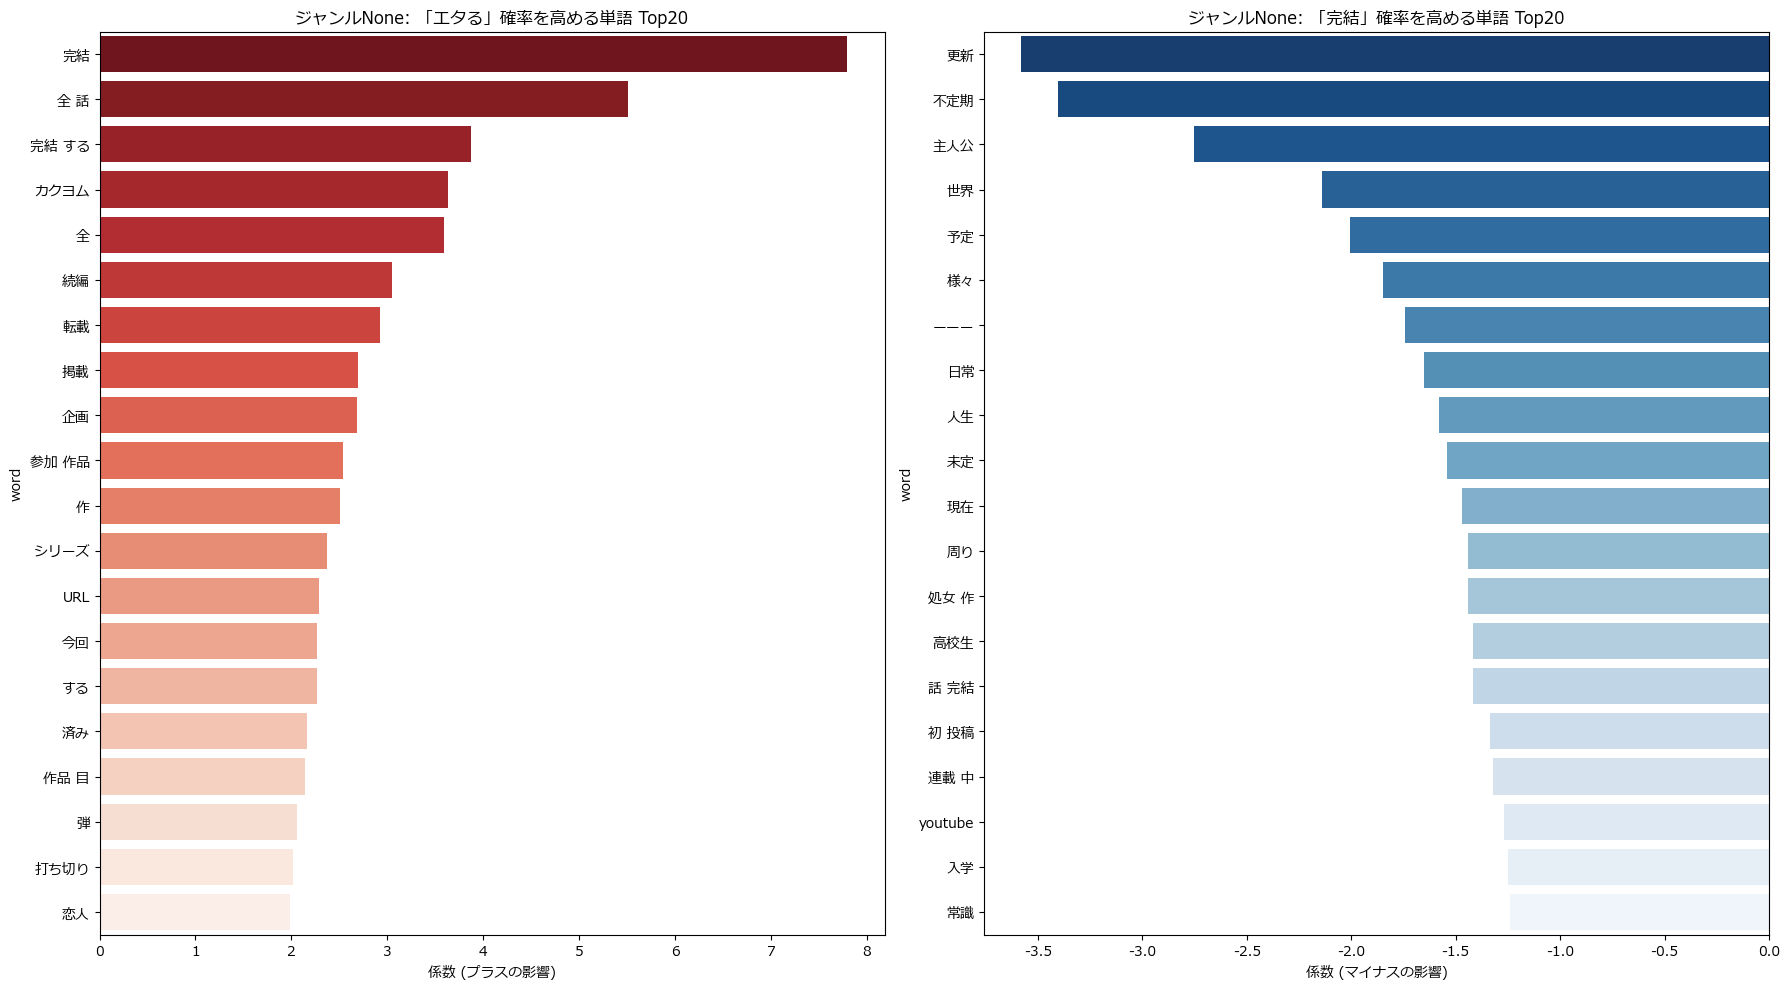

In [ ]:
# --- セル5: 重要単語の可視化 ---

if text_pipeline is not None:
    vectorizer = text_pipeline.named_steps['tfidf']
    model = text_pipeline.named_steps['clf']

    coefs = model.coef_[0]
    feature_names = vectorizer.get_feature_names_out()

    feature_importance = pd.DataFrame({
        'word': feature_names,
        'coefficient': coefs
    })

    top_eternal = feature_importance.sort_values(by='coefficient', ascending=False).head(20)
    top_complete = feature_importance.sort_values(by='coefficient', ascending=True).head(20)

    # グラフ描画
    fig, axes = plt.subplots(1, 2, figsize=(18, 10))

    sns.barplot(data=top_eternal, y='word', x='coefficient', ax=axes[0], palette='Reds_r')
    axes[0].set_title(f'ジャンル{TARGET_GENRE_ID}: 「エタる」確率を高める単語 Top20')
    axes[0].set_xlabel('係数 (プラスの影響)')

    sns.barplot(data=top_complete, y='word', x='coefficient', ax=axes[1], palette='Blues_r')
    axes[1].set_title(f'ジャンル{TARGET_GENRE_ID}: 「完結」確率を高める単語 Top20')
    axes[1].set_xlabel('係数 (マイナスの影響)')

    plt.tight_layout()
    plt.show()
else:
    print("モデルが作成されていません。")

In [ ]:
# --- セル6: 任意の文章でテスト ---

test_sentences = [
    "異世界に転生してチート能力で無双する物語です。",
    "ブラック企業に勤める男が、ある日突然、勇者として召喚される。",
    "昔ながらの純愛を描いた、切ないラブストーリー。ハッピーエンド確約。"
]

if text_pipeline is not None:
    print(f"--- 判定テスト (使用モデル: {best_params}) ---")
    for text in test_sentences:
        proba = text_pipeline.predict_proba([text])[0]
        pred = text_pipeline.predict([text])[0]
        
        label = "エタる" if pred == 1 else "完結"
        print(f"\nあらすじ: {text}")
        print(f"判定: {label} (エタる確率: {proba[1]*100:.1f}%)")

--- 判定テスト (使用モデル: {'max_features': 20000, 'C': 0.2}) ---

あらすじ: 異世界に転生してチート能力で無双する物語です。
判定: 完結 (エタる確率: 19.1%)

あらすじ: ブラック企業に勤める男が、ある日突然、勇者として召喚される。
判定: 完結 (エタる確率: 40.4%)

あらすじ: 昔ながらの純愛を描いた、切ないラブストーリー。ハッピーエンド確約。
判定: エタる (エタる確率: 58.0%)


In [ ]:
# --- セル7: モデルの保存 ---
save_dir = 'result_tfidf'
os.makedirs(save_dir, exist_ok=True)

# ファイル名にジャンル名を含める
save_filename = f'model_{genre_name}.pkl'
save_path = os.path.join(save_dir, save_filename)

if text_pipeline is not None:
    joblib.dump(text_pipeline, save_path)
    print(f"モデルを保存しました: {save_path}")
    print(f"保存されたモデルの設定: {best_params}")
    print("※次回分析時は、このモデルが読み込まれます。")
else:
    print("保存するモデルがありません。")

モデルを保存しました: result_tfidf\model_all.pkl
保存されたモデルの設定: {'max_features': 20000, 'C': 0.2}
※次回分析時は、このモデルが読み込まれます。
